# HMP

In [ ]:
import numpy as np
import mne
import hmp
import xarray as xr
from pathlib import Path


# ============================================================
# Alle sessies laden
# ============================================================

session_data = []

for ses in sessions:

    epo_file = output_dir / f"{sub}_{ses}_epo.fif"

    if not epo_file.exists():
        print(f"Skipping {ses}: file not found")
        continue

    epochs = mne.read_epochs(
        epo_file,
        preload=True,
        verbose=False
    )

    print(f"Loaded {ses}: {len(epochs)} trials")

    data = hmp.io.hmp_data_format(
        epochs.get_data(),
        epochs.info["sfreq"],
        tmin=epochs.tmin,
        tmax=epochs.tmax,
        channel=epochs.ch_names,
        metadata=epochs.metadata.reset_index(drop=True)
        if epochs.metadata is not None
        else None
    )

    # Voeg sessienaam toe als participant-dimensie
    if "participant" not in data.data.dims:
        data["data"] = data["data"].expand_dims(
            {"participant": [ses]}
        )

    session_data.append(data)

# ============================================================
# Controle
# ============================================================

if len(session_data) == 0:
    raise ValueError("Geen sessies gevonden.")

# ============================================================
# Sessies combineren
# ============================================================

epoch_data = xr.concat(
    session_data,
    dim="participant"
)

print("\nGecombineerde dataset:")
print(epoch_data)

print("\nSessies:")
print(epoch_data.participant.values)

# ============================================================
# PCA projectie
# ============================================================

preprocessed = hmp.transformers.ProjPCA(
    epoch_data,
    n_comp=5,
    interval_id="RT"
)

# ============================================================
# Verwacht HMP patroon
# ============================================================

expected_pattern = hmp.patterns.HalfSine.create_expected(
    sfreq=float(epoch_data.sfreq),
    width=50
)

# ============================================================
# Trial data maken
# ============================================================

trial_data = hmp.trialdata.TrialData.from_transformer(
    preprocessed.data,
    pattern=expected_pattern.template
)

# ============================================================
# Tijdsdistributie
# ============================================================

time_distribution = hmp.distributions.Gamma()

# ============================================================
# Model bouwen
# ============================================================

model = hmp.models.CumulativeMethod(
    expected_pattern,
    time_distribution
)

# ============================================================
# Model fitten
# ============================================================

print("\nFitting HMP model...")

loglikelihood, estimates = model.fit_transform(
    trial_data
)

print("\nModel succesvol gefit.")
print(f"Log-likelihood: {loglikelihood}")

# ============================================================
# Resultaten bekijken
# ============================================================

print("\nEstimates:")
print(estimates)

Loaded ses-0: 165 trials
Skipping ses-1: file not found
Loaded ses-2: 69 trials
Loaded ses-3: 82 trials
Loaded ses-4: 220 trials
Skipping ses-5: file not found
Loaded ses-6: 139 trials
Loaded ses-7: 172 trials
Skipping ses-8: file not found
Loaded ses-9: 171 trials
Loaded ses-10: 167 trials
Loaded ses-11: 202 trials
Loaded ses-12: 214 trials
Loaded ses-13: 194 trials
Loaded ses-14: 285 trials
Loaded ses-15: 283 trials
Loaded ses-16: 139 trials
Loaded ses-17: 231 trials
Loaded ses-18: 154 trials
Loaded ses-19: 258 trials


C:\Users\charl\AppData\Local\Temp\ipykernel_36308\1769070317.py:68: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'epoch' ('epoch',) The recommendation is to set join explicitly for this case.
  epoch_data = xr.concat(
C:\Users\charl\AppData\Local\Temp\ipykernel_36308\1769070317.py:68: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  epoch_data = xr.concat(



Gecombineerde dataset:
<xarray.Dataset> Size: 3GB
Dimensions:      (participant: 17, epoch: 285, channel: 102, sample: 820)
Coordinates:
  * participant  (participant) object 136B 'ses-0' 'ses-2' ... 'ses-18' 'ses-19'
  * epoch        (epoch) int64 2kB 0 1 2 3 4 5 6 ... 278 279 280 281 282 283 284
    trial_type   (participant, epoch) object 39kB 'RECOG_LURE' ... nan
    onset        (participant, epoch) float64 39kB 3.857e+03 3.863e+03 ... nan
    onset_resp   (participant, epoch) float64 39kB 3.858e+03 3.865e+03 ... nan
    RT           (participant, epoch) float64 39kB 1.592 1.856 1.316 ... nan nan
    correct      (participant, epoch) float64 39kB 1.0 1.0 1.0 ... nan nan nan
  * channel      (channel) <U4 2kB 'E4' 'E5' 'E6' 'E7' ... 'E120' 'E121' 'E124'
  * sample       (sample) int64 7kB -256 -255 -254 -253 -252 ... 560 561 562 563
Data variables:
    data         (participant, epoch, channel, sample) float64 3GB 2.548e-06 ...
Attributes:
    sfreq:    256.0

Sessies:
['ses-0' 's

  0%|          | 0/13 [00:00<?, ?it/s]

1 events found around times [50]
2 events found around times [35, 214]
3 events found around times [35, 210, 699]
Found 3 events

Model succesvol gefit.
Log-likelihood: [-13294.02144769]

Estimates:
<xarray.DataArray (trial: 3145, sample: 511, event: 3)> Size: 39MB
array([[[0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [5.66184849e-02, 0.00000000e+00, 0.00000000e+00],
        [8.35955415e-02, 8.36486553e-06, 0.00000000e+00],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

       [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [2.30658119e-02, 0.00000000e+00, 0.00000000e+00],
        [3.80433932e-02, 4.57120321e-05, 0.00000000e+00],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

       [

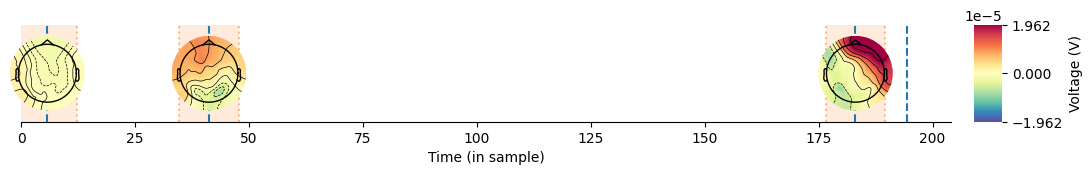

In [7]:
from mne.io import read_info

info = read_info(output_dir / f'sub-LTP063_ses-11_epo.fif', verbose=False)

hmp.visu.plot_topo_timecourse(epoch_data, estimates, #Data and estimations
                               info,#position of the electrodes and initialized model
                               magnify=1, sensors=False)#Display control parameters

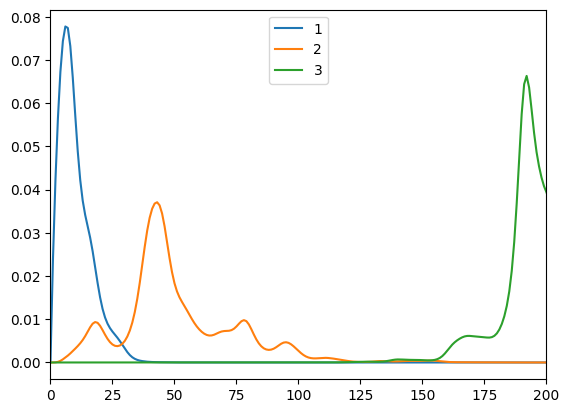

In [8]:
import matplotlib.pyplot as plt

plt.plot(estimates.isel(trial=-1), label=[1,2,3])
plt.xlim(0,200)
plt.legend()

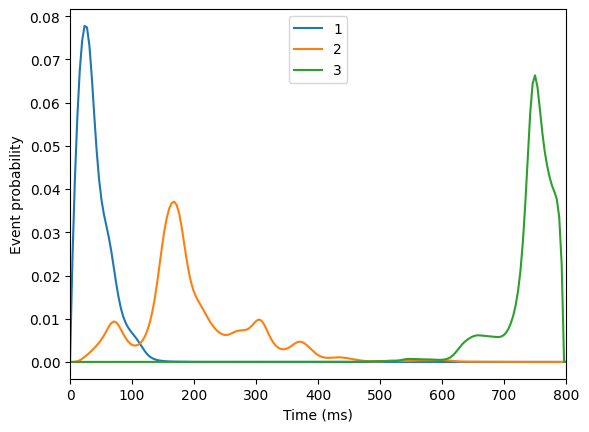

In [9]:
n_events = estimates.sizes['event']
times_ms = estimates.sample.values / epochs.info['sfreq'] * 1000

plt.plot(times_ms, estimates.isel(trial=-1), label=list(range(1, n_events + 1)))
plt.xlim(0, 800)
plt.xlabel('Time (ms)')
plt.ylabel('Event probability')
plt.legend()
plt.show()